# Tarea 7: Clasificación de Texto con Naive Bayes
## Análisis de Sentimiento en Reseñas de Películas

**Nombre:** Kelly Naomi Medina Guallo  
**Fecha:** 18/06/2026

### Objetivo:
Familiarizar al estudiante con el algoritmo Naive Bayes para clasificación de texto, aplicando técnicas de preprocesamiento como Bag of Words (CountVectorizer) y TF-IDF, analizando el efecto de hiperparámetros como `alpha` (suavizado Laplaciano) y n-gramas, y evaluando el modelo mediante métricas de precisión, recall y F1-score.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.
6. NO ELIMINAR NINGÚN COMENTARIO

### Descripción del Dataset:
Utilizaremos el dataset **Rotten Tomatoes Movie Reviews** que contiene reseñas de críticos de cine. Cada reseña está clasificada como:
- **fresh**: Reseña positiva
- **rotten**: Reseña negativa

### Archivo requerido:
- `critics.csv` - Dataset de reseñas de películas

## Parte 1: Configuración y Carga de Datos

In [2]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [3]:
# TODO: Cargar el dataset critics.csv
#
# Instrucciones:
critics = pd.read_csv('critics.csv')
print("Dimensiones", critics.shape)
print("Columnas:", critics.columns.tolist())
critics.head()

Dimensiones (27631, 8)
Columnas: ['critic', 'fresh', 'imdb', 'publication', 'quote', 'review_date', 'rtid', 'title']


,critic,fresh,imdb,publication,quote,review_date,rtid,title
0,Owen Gleiberman,fresh,114709,Entertainment Weekly,NaN,2011-09-07,9559,Toy story
1,Derek Adams,fresh,114709,Time Out,"So ingenious in concept, design and execution ...",2009-10-04,9559,Toy story
2,Richard Corliss,fresh,114709,TIME Magazine,The year's most inventive comedy.,2008-08-31,9559,Toy story
3,David Ansen,fresh,114709,Newsweek,A winning animated feature that has something ...,2008-08-18,9559,Toy story
4,Leonard Klady,fresh,114709,Variety,The film sports a provocative and appealing st...,2008-06-09,9559,Toy story


In [4]:
# TODO: Limpiar el dataset
#
# Instrucciones:
critics = critics[~critics.quote.isnull()]
critics = critics[critics['fresh'].isin(['fresh', 'rotten'])]
print("Dimensiones después de limpiar:", critics.shape)



Dimensiones después de limpiar: (15534, 8)


### Pregunta 1: Tamaño del Dataset
¿Cuántas reseñas válidas quedan después de limpiar el dataset?

A) Aproximadamente 5,000  
B) Aproximadamente 10,000  
C) Aproximadamente 15,000  
D) Aproximadamente 20,000  

**Su Respuesta:** C) Aproximadamente 15,000

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [25]:
# TODO: Explorar estadísticas básicas
#
# Instrucciones:
n_reviews = len(critics)
n_movies = critics.rtid.nunique()
n_critics = critics.critic.nunique()
# 4. Imprima las estadísticas
print(f"Total reseñas: {n_reviews}")
print(f"Total peliculas: {n_movies}")
print(f"Total criticos: {n_critics}")

Total reseñas: 15534
Total peliculas: 1921
Total criticos: 621


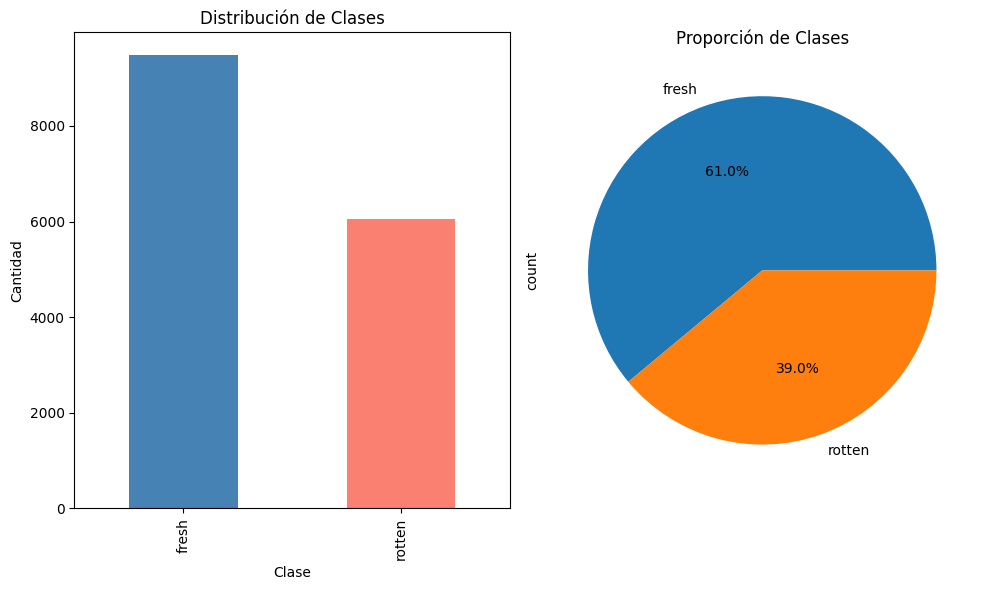

fresh
fresh     9482
rotten    6052
Name: count, dtype: int64


In [6]:
# TODO: Visualizar distribución de clases
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, use critics['fresh'].value_counts().plot(kind='bar')
# 3. En el segundo subplot, use .plot(kind='pie', autopct='%1.1f%%')
# 4. Agregue títulos y etiquetas
# 5. Imprima el conteo de clases

fig, axes = plt.subplots(1, 2)
critics['fresh'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'])
axes[0].set_title('Distribución de Clases')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
critics['fresh'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Proporción de Clases')
plt.tight_layout()
plt.show()
print(critics['fresh'].value_counts())

### Pregunta 2: Balance de Clases
¿Cuál es la clase mayoritaria en el dataset?

A) rotten (negativas)  
B) fresh (positivas)  
C) Están perfectamente balanceadas  
D) No se puede determinar  

**Su Respuesta:** B) fresh(positivas)

In [7]:
# TODO: Analizar longitud de las reseñas
#
# Instrucciones:
# 1. Cree una columna 'quote_length' con la longitud de cada quote: critics['quote'].apply(len)
# 2. Cree una columna 'word_count' con el número de palabras: critics['quote'].apply(lambda x: len(str(x).split()))
# 3. Imprima estadísticas descriptivas de estas columnas
# 4. Opcional: Cree histogramas comparando fresh vs rotten

critics['quote_length'] = critics['quote'].apply(len)
critics['word_count'] = critics['quote'].apply(lambda x: len(str(x).split()))
print(critics[['quote_length', 'word_count']].describe())


       quote_length    word_count
count  15534.000000  15534.000000
mean     117.014484     19.447534
std       57.581577      9.792644
min        4.000000      1.000000
25%       72.000000     12.000000
50%      114.000000     19.000000
75%      158.000000     26.000000
max      256.000000     49.000000


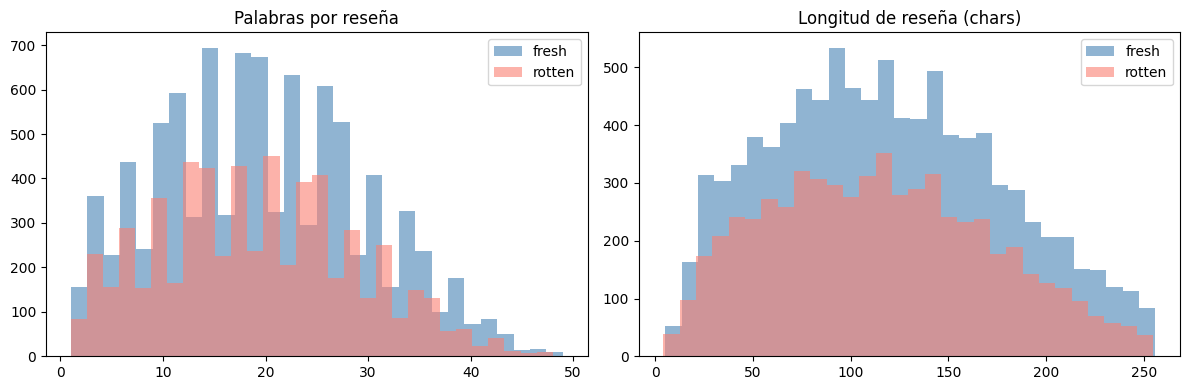

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, color in zip(['fresh', 'rotten'], ['steelblue', 'salmon']):
    subset = critics[critics['fresh'] == label]
    axes[0].hist(subset['word_count'], bins=30, alpha=0.6, label=label, color=color)
    axes[1].hist(subset['quote_length'], bins=30, alpha=0.6, label=label, color=color)
axes[0].set_title('Palabras por reseña')
axes[1].set_title('Longitud de reseña (chars)')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# TODO: Mostrar ejemplos de reseñas
#
# Instrucciones:
# 1. Imprima 3 ejemplos de reseñas 'fresh' usando critics[critics['fresh']=='fresh']['quote'].head(3)
# 2. Imprima 3 ejemplos de reseñas 'rotten'
print("=== RESEÑAS FRESH ===")
for q in critics[critics['fresh']=='fresh']['quote'].head(3):
    print("-", q)

print("\n=== RESEÑAS ROTTEN ===")
for q in critics[critics['fresh']=='rotten']['quote'].head(3):
    print("-", q)


=== RESEÑAS FRESH ===
- So ingenious in concept, design and execution that you could watch it on a postage stamp-sized screen and still be engulfed by its charm.
- The year's most inventive comedy.
- A winning animated feature that has something for everyone on the age spectrum.

=== RESEÑAS ROTTEN ===
- A gloomy special-effects extravaganza filled with grotesque images, generating fear and despair.
- Mediocre, regrettably.
- The movie is too pat and practiced to really be convincing, and the progress of Ariel's relationships with the two grumps seems dictated mostly by the needs of the screenplay.


## Parte 3: Preprocesamiento de Texto - Bag of Words

### Teoría:
El modelo **Bag of Words (BoW)** representa el texto como un vector de frecuencias de palabras, ignorando el orden. **CountVectorizer** de Scikit-Learn implementa este enfoque.

$$\text{Vector} = [\text{count}(w_1), \text{count}(w_2), ..., \text{count}(w_n)]$$

In [10]:
# TODO: Crear una función para preparar los datos
#
# Instrucciones:
# 1. Defina la función make_xy(data, vectorizer) que:
#    a. Aplique vectorizer.fit_transform(data['quote']) para obtener X
#    b. Convierta 'fresh' a binario: y = (data['fresh'] == 'fresh').astype(int).values
#    c. Retorne X, y

def make_xy(data, vectorizer):
    """Prepara los datos para el modelo."""
    # Su código aquí
    X = vectorizer.fit_transform(data['quote'])
    y = (data['fresh'] == 'fresh').astype(int).values
    return X, y


In [11]:
# TODO: Aplicar CountVectorizer
#
# Instrucciones:
# 1. Cree vectorizer = CountVectorizer(min_df=5)
# 2. Use make_xy() para obtener X, y
# 3. Imprima la forma de X y y
# 4. Imprima algunos ejemplos de palabras del vocabulario con vectorizer.get_feature_names_out()[:20]

vectorizer = CountVectorizer(min_df=5)
X, y = make_xy(critics, vectorizer)
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Primeras 20 palabras del vocabulario:", vectorizer.get_feature_names_out()[:20])

Forma de X: (15534, 6166)
Forma de y: (15534,)
Primeras 20 palabras del vocabulario: ['000' '007' '10' '100' '11' '12' '13' '13th' '15' '16' '17' '1930s'
 '1933' '1939' '1940s' '1950s' '1956' '1960s' '1961' '1963']


### Pregunta 3: Dimensiones del Vocabulario
¿Aproximadamente cuántas características (palabras únicas) tiene el vocabulario con min_df=5?

A) 500-1,000  
B) 1,000-5,000  
C) 5,000-10,000  
D) 10,000-20,000  

**Su Respuesta:** C) 5,000 - 10,000

In [12]:
# TODO: Dividir en train y test
#
# Instrucciones:
# 1. Use train_test_split(X, y, test_size=0.3, random_state=42)
# 2. Asigne a X_train, X_test, y_train, y_test
# 3. Imprima los tamaños de cada conjunto
# 4. Imprima la distribución de clases en entrenamiento

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Distribución clases train:", pd.Series(y_train).value_counts().to_dict())

Train: (10873, 6166), Test: (4661, 6166)
Distribución clases train: {1: 6623, 0: 4250}


## Parte 4: Naive Bayes Multinomial

### Teoría - Teorema de Bayes:
$$P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}$$

**Naive Bayes** asume independencia condicional entre características:
$$P(X|C) = P(x_1|C) \cdot P(x_2|C) \cdot ... \cdot P(x_n|C)$$

**Multinomial Naive Bayes** es apropiado para conteos de palabras.

In [13]:
# TODO: Entrenar Multinomial Naive Bayes
#
# Instrucciones:
# 1. Cree el modelo: clf_nb = MultinomialNB()
# 2. Entrene con clf_nb.fit(X_train, y_train)
# 3. Prediga en train y test
# 4. Calcule y muestre las precisiones en train y test con accuracy_score()

clf_nb = MultinomialNB()
clf_nb.fit(X_train, y_train)
y_pred_train = clf_nb.predict(X_train)
y_pred_test = clf_nb.predict(X_test)
print(f"Precisión Train: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Precisión Test:  {accuracy_score(y_test, y_pred_test):.4f}")

Precisión Train: 0.8709
Precisión Test:  0.7670


### Pregunta 4: Precisión del Modelo Base
¿Cuál es la precisión aproximada del modelo Naive Bayes en el conjunto de prueba?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B) 70-80%

## Parte 5: Matriz de Confusión y Métricas

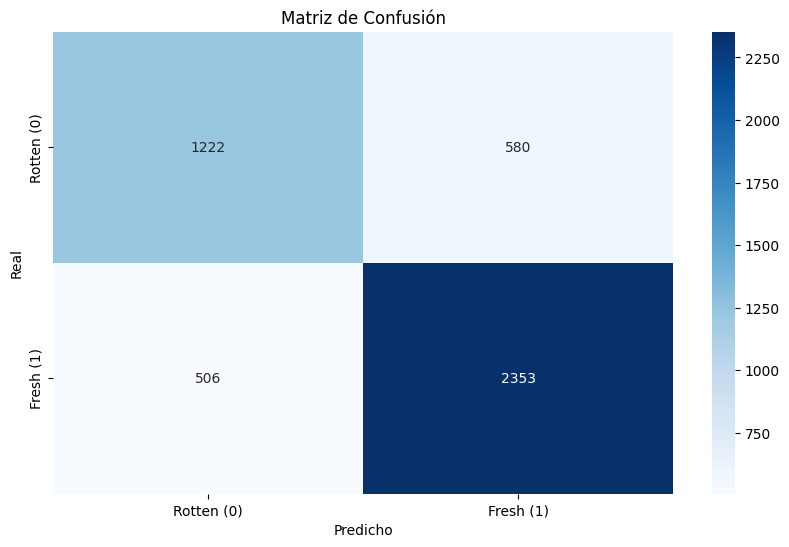

TN=1222, FP=580, FN=506, TP=2353


In [14]:
# TODO: Calcular y visualizar la matriz de confusión
#
# Instrucciones:
# 1. Calcule cm = confusion_matrix(y_test, y_pred_test)
# 2. Visualice con sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# 3. Configure xticklabels y yticklabels como ['Rotten (0)', 'Fresh (1)']
# 4. Imprima TN, FP, FN, TP

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rotten (0)', 'Fresh (1)'],
            yticklabels=['Rotten (0)', 'Fresh (1)'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()
TN, FP, FN, TP = cm.ravel()
print(f"TN={TN}, FP={FP}, FN={FN}, TP={TP}")

In [15]:
# TODO: Calcular métricas detalladas
#
# Instrucciones:
# 1. Calcule precision = precision_score(y_test, y_pred_test)
# 2. Calcule recall = recall_score(y_test, y_pred_test)
# 3. Calcule f1 = f1_score(y_test, y_pred_test)
# 4. Imprima las métricas
# 5. Use classification_report() para el reporte completo

precision = precision_score(y_test, y_pred_test)
recall    = recall_score(y_test, y_pred_test)
f1        = f1_score(y_test, y_pred_test)
print(f"Precisión: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\n", classification_report(y_test, y_pred_test, target_names=['Rotten','Fresh']))

Precisión: 0.8023
Recall:    0.8230
F1-Score:  0.8125

               precision    recall  f1-score   support

      Rotten       0.71      0.68      0.69      1802
       Fresh       0.80      0.82      0.81      2859

    accuracy                           0.77      4661
   macro avg       0.75      0.75      0.75      4661
weighted avg       0.77      0.77      0.77      4661



### Pregunta 5: Interpretación de Métricas
Si el modelo tiene alto recall pero baja precisión para la clase 'Fresh', ¿qué significa?

A) El modelo detecta bien las reseñas positivas pero también clasifica muchas negativas como positivas  
B) El modelo no detecta las reseñas positivas  
C) El modelo es perfecto  
D) El modelo solo predice negativas  

**Su Respuesta:** A) El modelo detecta bien las reseñas positivas pero también clasifica muchas negativas como positivas  

## Parte 6: Efecto del Parámetro Alpha (Suavizado Laplaciano)

### Teoría:
El parámetro `alpha` es el **suavizado de Laplace** (additive smoothing). Evita probabilidades de cero para palabras no vistas:

$$P(w|C) = \frac{\text{count}(w,C) + \alpha}{\text{count}(C) + \alpha \cdot |V|}$$

- alpha=1.0: Suavizado estándar (default)
- alpha<1.0: Menos suavizado
- alpha>1.0: Más suavizado

In [16]:
# TODO: Experimentar con diferentes valores de alpha
#
# Instrucciones:
# 1. Defina alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
# 2. Para cada alpha:
#    a. Cree MultinomialNB(alpha=alpha)
#    b. Entrene y calcule precisiones train/test
#    c. Calcule precision y recall
# 3. Guarde resultados en un DataFrame e imprima

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
resultados = []
for alpha in alphas:
    m = MultinomialNB(alpha=alpha)
    m.fit(X_train, y_train)
    tr = accuracy_score(y_train, m.predict(X_train))
    te = accuracy_score(y_test,  m.predict(X_test))
    pr = precision_score(y_test, m.predict(X_test))
    rc = recall_score(y_test,    m.predict(X_test))
    resultados.append({'alpha': alpha, 'train_acc': tr, 'test_acc': te, 'precision': pr, 'recall': rc})
df_alpha = pd.DataFrame(resultados)
print(df_alpha)

    alpha  train_acc  test_acc  precision    recall
0   0.001   0.884668  0.751555   0.784925  0.819517
1   0.010   0.884117  0.754988   0.788766  0.820217
2   0.100   0.880898  0.761854   0.797146  0.820567
3   0.500   0.876759  0.764643   0.802126  0.818118
4   1.000   0.870873  0.767003   0.802250  0.823015
5   2.000   0.863975  0.768934   0.796210  0.837705
6   5.000   0.839787  0.755203   0.752945  0.894369
7  10.000   0.766302  0.714010   0.693852  0.955229


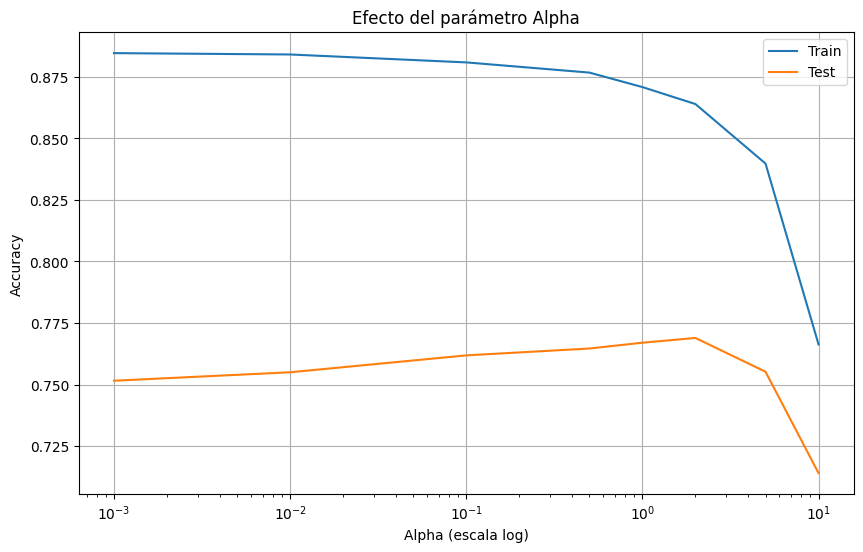

In [17]:
# TODO: Visualizar el efecto de alpha
#
# Instrucciones:
# 1. Grafique train_scores y test_scores vs alphas
# 2. Use plt.xscale('log') para escala logarítmica
# 3. Agregue leyenda, título y etiquetas

plt.plot(df_alpha['alpha'], df_alpha['train_acc'], label='Train')
plt.plot(df_alpha['alpha'], df_alpha['test_acc'],  label='Test')
plt.xscale('log')
plt.xlabel('Alpha (escala log)')
plt.ylabel('Accuracy')
plt.title('Efecto del parámetro Alpha')
plt.legend()
plt.grid(True)
plt.show()

### Pregunta 6: Efecto de Alpha
¿Qué ocurre cuando alpha es muy pequeño (ej: 0.001)?

A) El modelo generaliza mejor  
B) El modelo tiende a sobreajustar (train acc >> test acc)  
C) El modelo no aprende nada  
D) No hay efecto significativo  

**Su Respuesta:** B) El modelo tiende a sobreajustar (train acc >> test acc)

## Parte 7: N-gramas

### Teoría:
Los **n-gramas** capturan secuencias de n palabras consecutivas:
- Unigrama (1-gram): palabras individuales
- Bigrama (2-gram): pares de palabras
- Trigrama (3-gram): tríos de palabras

Ejemplo: "I love this movie"
- Unigramas: ["I", "love", "this", "movie"]
- Bigramas: ["I love", "love this", "this movie"]

In [18]:
# TODO: Experimentar con diferentes n-gramas
#
# Instrucciones:
# 1. Defina ngram_configs = [(1,1), (1,2), (2,2), (1,3), (2,3)]
# 2. Para cada configuración:
#    a. Cree CountVectorizer(ngram_range=ngram, min_df=5)
#    b. Use make_xy() para crear X, y
#    c. Divida en train/test
#    d. Entrene MultinomialNB y calcule precisiones
# 3. Imprima los resultados comparativos

ngram_configs = [(1,1), (1,2), (2,2), (1,3), (2,3)]
for ngram in ngram_configs:
    vec = CountVectorizer(ngram_range=ngram, min_df=5)
    Xn, yn = make_xy(critics, vec)
    Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn, test_size=0.3, random_state=42)
    m = MultinomialNB()
    m.fit(Xn_tr, yn_tr)
    tr = accuracy_score(yn_tr, m.predict(Xn_tr))
    te = accuracy_score(yn_te, m.predict(Xn_te))
    print(f"ngram={ngram} | vocab={Xn.shape[1]} | train={tr:.4f} | test={te:.4f}")

ngram=(1, 1) | vocab=6166 | train=0.8709 | test=0.7670
ngram=(1, 2) | vocab=13054 | train=0.8956 | test=0.7719
ngram=(2, 2) | vocab=6888 | train=0.8230 | test=0.6896
ngram=(1, 3) | vocab=14727 | train=0.8935 | test=0.7659
ngram=(2, 3) | vocab=8561 | train=0.8210 | test=0.6803


### Pregunta 7: N-gramas
¿Qué ocurre al usar solo bigramas (2,2) en comparación con unigramas (1,1)?

A) Siempre mejora la precisión  
B) Aumenta mucho el número de características y puede sobreajustar  
C) Reduce el número de características  
D) No tiene ningún efecto  

**Su Respuesta:** B) Aumenta mucho el número de características y puede sobreajustar

## Parte 8: TF-IDF

### Teoría:
**TF-IDF** (Term Frequency - Inverse Document Frequency) pondera las palabras por su importancia:

$$\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t)$$

Donde:
- TF(t,d): Frecuencia del término t en el documento d
- IDF(t): log(N / df(t)) - penaliza palabras muy comunes

In [19]:
# TODO: Aplicar TF-IDF
#
# Instrucciones:
# 1. Cree tfidf_vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
# 2. Use make_xy() para crear X_tfidf, y_tfidf
# 3. Divida en train/test
# 4. Entrene MultinomialNB
# 5. Calcule y muestre precisiones train/test

tfidf_vectorizer = TfidfVectorizer(min_df=5, stop_words='english')
X_tfidf, y_tfidf = make_xy(critics, tfidf_vectorizer)
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_tfidf, y_tfidf, test_size=0.3, random_state=42)
clf_tfidf = MultinomialNB()
clf_tfidf.fit(Xt_tr, yt_tr)
print(f"TF-IDF Train: {accuracy_score(yt_tr, clf_tfidf.predict(Xt_tr)):.4f}")
print(f"TF-IDF Test:  {accuracy_score(yt_te, clf_tfidf.predict(Xt_te)):.4f}")

TF-IDF Train: 0.8459
TF-IDF Test:  0.7425


In [20]:
# TODO: Imprimir reporte de clasificación con TF-IDF
#
# Instrucciones:
# 1. Prediga con el modelo TF-IDF
# 2. Use classification_report() para el reporte

yt_pred = clf_tfidf.predict(Xt_te)
print(classification_report(yt_te, yt_pred, target_names=['Rotten','Fresh']))

              precision    recall  f1-score   support

      Rotten       0.79      0.46      0.58      1802
       Fresh       0.73      0.92      0.81      2859

    accuracy                           0.74      4661
   macro avg       0.76      0.69      0.70      4661
weighted avg       0.75      0.74      0.72      4661



### Pregunta 8: TF-IDF vs CountVectorizer
¿Cuál es una ventaja de TF-IDF sobre CountVectorizer simple?

A) Siempre da mejor precisión  
B) Penaliza palabras muy comunes y reduce el sobreajuste  
C) Usa menos memoria  
D) Es más rápido de calcular  

**Su Respuesta:** B) Penaliza palabras muy comunes y reduce el sobreajuste  

## Parte 9: Interpretación del Modelo

In [21]:
# TODO: Identificar las palabras más predictivas
#
# Instrucciones:
# 1. Obtenga los nombres de características: feature_names = np.array(vectorizer.get_feature_names_out())
# 2. Obtenga log probabilidades: clf_nb.feature_log_prob_[1] (Fresh) y clf_nb.feature_log_prob_[0] (Rotten)
# 3. Calcule la diferencia: log_ratio = log_prob_fresh - log_prob_rotten
# 4. Use argsort() para encontrar las 15 palabras más positivas y negativas
# 5. Imprima las palabras con sus log ratios

feature_names   = np.array(vectorizer.get_feature_names_out())
log_prob_fresh  = clf_nb.feature_log_prob_[1]
log_prob_rotten = clf_nb.feature_log_prob_[0]
log_ratio = log_prob_fresh - log_prob_rotten

top_pos = np.argsort(log_ratio)[-15:][::-1]
top_neg = np.argsort(log_ratio)[:15]

print("=== Palabras más asociadas a FRESH ===")
for i in top_pos:
    print(f"  {feature_names[i]:20s}  {log_ratio[i]:.3f}")

print("\n=== Palabras más asociadas a ROTTEN ===")
for i in top_neg:
    print(f"  {feature_names[i]:20s}  {log_ratio[i]:.3f}")

=== Palabras más asociadas a FRESH ===
  delight               3.146
  superb                2.895
  richly                2.607
  bold                  2.607
  captures              2.559
  rousing               2.507
  gentle                2.507
  innocence             2.507
  winning               2.453
  intimate              2.453
  touching              2.356
  irresistible          2.335
  kurosawa              2.335
  myth                  2.335
  childhood             2.271

=== Palabras más asociadas a ROTTEN ===
  lame                  -3.528
  pointless             -3.382
  uninspired            -3.270
  unfortunately         -3.210
  unfunny               -2.835
  witless               -2.835
  charmless             -2.740
  repetitive            -2.740
  monotonous            -2.740
  resembles             -2.740
  forgettable           -2.740
  unsatisfying          -2.740
  bland                 -2.671
  fault                 -2.634
  besson                -2.634


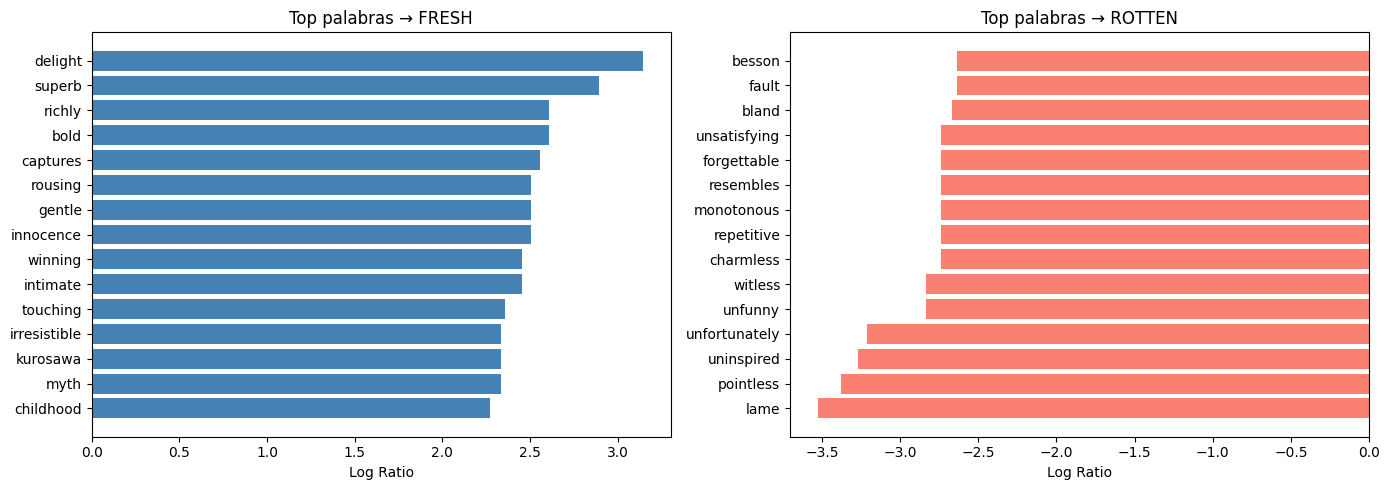

In [22]:
# TODO: Visualizar las palabras más predictivas
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, grafique las palabras más positivas con barh()
# 3. En el segundo subplot, grafique las palabras más negativas
# 4. Agregue títulos y etiquetas

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_pos][::-1], log_ratio[top_pos][::-1], color='steelblue')
axes[0].set_title('Top palabras → FRESH')
axes[0].set_xlabel('Log Ratio')

axes[1].barh(feature_names[top_neg], log_ratio[top_neg], color='salmon')
axes[1].set_title('Top palabras → ROTTEN')
axes[1].set_xlabel('Log Ratio')

plt.tight_layout()
plt.show()

### Pregunta 9: Interpretabilidad
¿Qué tipo de palabras esperaría encontrar asociadas a reseñas negativas?

A) Palabras como "excellent", "amazing", "brilliant"  
B) Palabras como "boring", "bad", "disappointing"  
C) Palabras neutrales como "the", "and", "is"  
D) Nombres de actores  

**Su Respuesta:** B) Palabras como "boring", "bad", "disappointing"  

## Parte 10: Predicción con Nuevas Reseñas

In [23]:
# TODO: Probar el modelo con nuevas reseñas
#
# Instrucciones:
# 1. Defina una lista de nuevas reseñas de ejemplo
# 2. Transforme con vectorizer.transform(new_reviews)
# 3. Prediga con clf_nb.predict()
# 4. Obtenga probabilidades con clf_nb.predict_proba()
# 5. Imprima cada reseña con su predicción y probabilidades

new_reviews = [
    "This movie is absolutely amazing! Best film of the year!",
    "Terrible waste of time. Boring and predictable.",
    "A decent film with good performances but weak plot.",
    "Masterpiece! Incredible acting and stunning visuals.",
    "I've seen better. Nothing special about this one."
]

# Su código aquí
X_new = vectorizer.transform(new_reviews)
predicciones = clf_nb.predict(X_new)
probabilidades = clf_nb.predict_proba(X_new)

for i, review in enumerate(new_reviews):
    etiqueta = 'FRESH' if predicciones[i] == 1 else 'ROTTEN'
    prob_r = probabilidades[i][0]
    prob_f = probabilidades[i][1]
    print(f"Reseña: {review[:50]}...")
    print(f"  Predicción: {etiqueta} | P(Rotten)={prob_r:.3f} | P(Fresh)={prob_f:.3f}\n")

Reseña: This movie is absolutely amazing! Best film of the...
  Predicción: FRESH | P(Rotten)=0.025 | P(Fresh)=0.975

Reseña: Terrible waste of time. Boring and predictable....
  Predicción: ROTTEN | P(Rotten)=0.985 | P(Fresh)=0.015

Reseña: A decent film with good performances but weak plot...
  Predicción: FRESH | P(Rotten)=0.452 | P(Fresh)=0.548

Reseña: Masterpiece! Incredible acting and stunning visual...
  Predicción: FRESH | P(Rotten)=0.005 | P(Fresh)=0.995

Reseña: I've seen better. Nothing special about this one....
  Predicción: ROTTEN | P(Rotten)=0.657 | P(Fresh)=0.343



### Pregunta 10: Predicciones
¿Qué método se usa para obtener las probabilidades de cada clase?

A) predict()  
B) predict_proba()  
C) score()  
D) fit()  

**Su Respuesta:** B) predict_proba()

## Parte 11: Comparación de Modelos

In [24]:
# TODO: Comparar Multinomial vs Bernoulli Naive Bayes
#
# Instrucciones:
# 1. Cree y entrene BernoulliNB() con los mismos datos
# 2. Calcule precisiones train/test
# 3. Cree un DataFrame comparando:
#    - Multinomial NB
#    - Bernoulli NB
#    - Multinomial + TF-IDF
# 4. Imprima la tabla comparativa

clf_ber = BernoulliNB()
clf_ber.fit(X_train, y_train)

resultados_comp = pd.DataFrame([
    {
        'Modelo': 'Multinomial NB',
        'Train Acc': accuracy_score(y_train, clf_nb.predict(X_train)),
        'Test Acc':  accuracy_score(y_test,  clf_nb.predict(X_test))
    },
    {
        'Modelo': 'Bernoulli NB',
        'Train Acc': accuracy_score(y_train, clf_ber.predict(X_train)),
        'Test Acc':  accuracy_score(y_test,  clf_ber.predict(X_test))
    },
    {
        'Modelo': 'Multinomial + TF-IDF',
        'Train Acc': accuracy_score(yt_tr, clf_tfidf.predict(Xt_tr)),
        'Test Acc':  accuracy_score(yt_te, clf_tfidf.predict(Xt_te))
    }
])
print(resultados_comp.to_string(index=False))

              Modelo  Train Acc  Test Acc
      Multinomial NB   0.870873  0.767003
        Bernoulli NB   0.870229  0.769577
Multinomial + TF-IDF   0.845857  0.742545


### Pregunta 11: Multinomial vs Bernoulli
¿Cuál es la diferencia principal entre Multinomial y Bernoulli Naive Bayes?

A) No hay diferencia  
B) Multinomial usa conteos de palabras, Bernoulli usa presencia/ausencia binaria  
C) Bernoulli es siempre mejor  
D) Multinomial solo funciona con TF-IDF  

**Su Respuesta:** B) Multinomial usa conteos de palabras, Bernoulli usa presencia/ausencia binaria

### Pregunta 12: Suposición de Naive Bayes
¿Cuál es la suposición principal del algoritmo Naive Bayes?

A) Las características tienen distribución normal  
B) Las características son independientes dada la clase  
C) Los datos deben estar normalizados  
D) Debe haber balance de clases  

**Su Respuesta:** B) Las características son independientes dada la clase

### Pregunta 13: Ventajas de Naive Bayes
¿Cuál es una ventaja de Naive Bayes para clasificación de texto?

A) Siempre da la mejor precisión  
B) Es rápido de entrenar y funciona bien con alta dimensionalidad  
C) No requiere preprocesamiento  
D) Captura relaciones complejas entre palabras  

**Su Respuesta:** B) Es rápido de entrenar y funciona bien con alta dimensionalidad

### Pregunta 14: Stop Words
¿Qué son las "stop words" en procesamiento de texto?

A) Palabras con errores ortográficos  
B) Palabras muy comunes que aportan poca información (the, is, and)  
C) Palabras negativas  
D) Palabras técnicas  

**Su Respuesta:** B) Palabras muy comunes que aportan poca información (the, is, and)

### Pregunta 15: min_df en CountVectorizer
¿Qué hace el parámetro min_df=5 en CountVectorizer?

A) Limita a 5 palabras por documento  
B) Ignora palabras que aparecen en menos de 5 documentos  
C) Usa solo las 5 palabras más frecuentes  
D) Divide los datos en 5 partes  

**Su Respuesta:** B) Ignora palabras que aparecen en menos de 5 documentos

## ¡Excelente Trabajo!

Responda las preguntas basadas en sus ejecuciones. Entregue el notebook completado con todas las celdas ejecutadas.